In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

PROJECT_PATH = '/content/drive/MyDrive/DataMining_Project'

data_path = f'{PROJECT_PATH}/data/Womens Clothing E-Commerce Reviews.csv'
df = pd.read_csv(data_path)

print("Orijinal Veri Seti Boyutu:", df.shape)

if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

print("\nTemizlik Öncesi Eksik Veriler:\n", df.isnull().sum())

df = df.dropna(subset=['Review Text'])

df['Title'] = df['Title'].fillna("")

df['Division Name'] = df['Division Name'].fillna("Unknown")
df['Department Name'] = df['Department Name'].fillna("Unknown")
df['Class Name'] = df['Class Name'].fillna("Unknown")

print("\nTemizlik Sonrası Eksik Veriler:\n", df.isnull().sum())
print("\nTemizlenmiş Veri Seti Boyutu:", df.shape)

clean_data_path = f'{PROJECT_PATH}/data/Cleaned_ECommerce_Reviews.csv'
df.to_csv(clean_data_path, index=False)

print(f"\nVeri kaydedildi: {clean_data_path}")

Orijinal Veri Seti Boyutu: (23486, 11)

Temizlik Öncesi Eksik Veriler:
 Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

Temizlik Sonrası Eksik Veriler:
 Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
dtype: int64

Temizlenmiş Veri Seti Boyutu: (22641, 10)

Veri kaydedildi: /content/drive/MyDrive/DataMining_Project/data/Cleaned_ECommerce_Reviews.csv


In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

PROJECT_PATH = '/content/drive/MyDrive/DataMining_Project'
df = pd.read_csv(f'{PROJECT_PATH}/data/Cleaned_ECommerce_Reviews.csv')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def process_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(cleaned_words)

print("NLP işlemi başlıyor...")
df['Processed_Review'] = df['Review Text'].apply(process_text)

print(df[['Review Text', 'Processed_Review']].head())

output_path = f'{PROJECT_PATH}/data/NLP_Processed_Reviews.csv'
df.to_csv(output_path, index=False)
print(f"NLP işlemi tamamlandı. Şuraya kaydedildi: {output_path}")

NLP işlemi başlıyor...
                                         Review Text  \
0  Absolutely wonderful - silky and sexy and comf...   
1  Love this dress!  it's sooo pretty.  i happene...   
2  I had such high hopes for this dress and reall...   
3  I love, love, love this jumpsuit. it's fun, fl...   
4  This shirt is very flattering to all due to th...   

                                    Processed_Review  
0        absolutely wonderful silky sexy comfortable  
1  love dress sooo pretty happened find store im ...  
2  high hope dress really wanted work initially o...  
3  love love love jumpsuit fun flirty fabulous ev...  
4  shirt flattering due adjustable front tie perf...  
NLP işlemi tamamlandı. Şuraya kaydedildi: /content/drive/MyDrive/DataMining_Project/data/NLP_Processed_Reviews.csv


In [ ]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon', quiet=True)

PROJECT_PATH = '/content/drive/MyDrive/DataMining_Project'
df = pd.read_csv(f'{PROJECT_PATH}/data/NLP_Processed_Reviews.csv')

sia = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
    if pd.isna(text) or str(text).strip() == "":
        return 0.0
    return sia.polarity_scores(str(text))['compound']

print("Duygu analizi yapılıyor ve yeni özellikler türetiliyor...")

df['Sentiment_Score'] = df['Processed_Review'].apply(get_sentiment_score)

df['Word_Count'] = df['Processed_Review'].apply(lambda x: len(str(x).split()))

print("\nTüretilen Yeni Özellikler:")
print(df[['Processed_Review', 'Sentiment_Score', 'Word_Count']].head())

output_path = f'{PROJECT_PATH}/data/Feature_Engineered_Reviews.csv'
df.to_csv(output_path, index=False)
print(f"\nYeni veri seti kaydedildi: {output_path}")

Duygu analizi yapılıyor ve yeni özellikler türetiliyor...

Türetilen Yeni Özellikler:
                                    Processed_Review  Sentiment_Score  \
0        absolutely wonderful silky sexy comfortable           0.8991   
1  love dress sooo pretty happened find store im ...           0.9710   
2  high hope dress really wanted work initially o...           0.9081   
3  love love love jumpsuit fun flirty fabulous ev...           0.9437   
4  shirt flattering due adjustable front tie perf...           0.9062   

   Word_Count  
0           5  
1          30  
2          48  
3          14  
4          16  

Yeni veri seti kaydedildi: /content/drive/MyDrive/DataMining_Project/data/Feature_Engineered_Reviews.csv


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

PROJECT_PATH = '/content/drive/MyDrive/DataMining_Project'
df = pd.read_csv(f'{PROJECT_PATH}/data/Feature_Engineered_Reviews.csv')

tfidf = TfidfVectorizer(max_features=1000)

print("Kelimeler matematiksel vektörlere dönüştürülüyor...")

tfidf_matrix = tfidf.fit_transform(df['Processed_Review'].fillna(""))

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

final_df = pd.concat([df, tfidf_df], axis=1)

print("\nGüncel Veri Seti Boyutu:", final_df.shape)

output_path = f'{PROJECT_PATH}/data/Final_Machine_Learning_Data.csv'
final_df.to_csv(output_path, index=False)

joblib.dump(tfidf, f'{PROJECT_PATH}/src/tfidf_vectorizer.pkl')

print(f"\nTüm veriler başarıyla birleştirildi ve şuraya kaydedildi: {output_path}")

Kelimeler matematiksel vektörlere dönüştürülüyor...

Güncel Veri Seti Boyutu: (22641, 1013)

Tüm veriler başarıyla birleştirildi ve şuraya kaydedildi: /content/drive/MyDrive/DataMining_Project/data/Final_Machine_Learning_Data.csv


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

PROJECT_PATH = '/content/drive/MyDrive/DataMining_Project'

print("Veri seti yükleniyor...")
df = pd.read_csv(f'{PROJECT_PATH}/data/Final_Machine_Learning_Data.csv')

# Gereksiz sütunların çıkarılması
cols_to_drop = ['Review Text', 'Title', 'Processed_Review', 'Clothing ID', 'Rating']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# One Hot Encoding
categorical_cols = ['Division Name', 'Department Name', 'Class Name']
df = pd.get_dummies(df, columns=[col for col in categorical_cols if col in df.columns], drop_first=True)

y = df['Recommended IND']
X = df.drop(columns=['Recommended IND'])

print(f"Model {X.shape[1]} adet özellik (sütun) üzerinden eğitilecek.")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
num_cols = ['Age', 'Sentiment_Score', 'Word_Count']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Veri başarıyla bölündü ve ölçeklendirildi!")

Veri seti yükleniyor...
Model 1033 adet özellik (sütun) üzerinden eğitilecek.
Veri başarıyla bölündü ve ölçeklendirildi!


Lojistik Regresyon modeli eğitiliyor...

🎯 MODEL PERFORMANS SONUÇLARI (LOJİSTİK REGRESYON)
Genel Doğruluk (Accuracy): 0.8858

Sınıflandırma Raporu (Classification Report):
              precision    recall  f1-score   support

           0       0.76      0.54      0.63       820
           1       0.90      0.96      0.93      3709

    accuracy                           0.89      4529
   macro avg       0.83      0.75      0.78      4529
weighted avg       0.88      0.89      0.88      4529



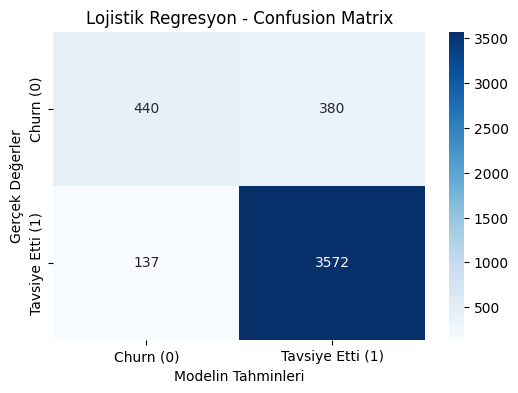

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Lojistik Regresyon modeli eğitiliyor...")

# Model eğitimi
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

# Metrikler
print("\n" + "="*50)
print("🎯 MODEL PERFORMANS SONUÇLARI (LOJİSTİK REGRESYON)")
print("="*50)

accuracy = accuracy_score(y_test, y_pred)
print(f"Genel Doğruluk (Accuracy): {accuracy:.4f}\n")

print("Sınıflandırma Raporu (Classification Report):")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Churn (0)', 'Tavsiye Etti (1)'], yticklabels=['Churn (0)', 'Tavsiye Etti (1)'])
plt.title('Lojistik Regresyon - Confusion Matrix')
plt.ylabel('Gerçek Değerler')
plt.xlabel('Modelin Tahminleri')
plt.show()

Random Forest modeli eğitiliyor...

🌲 MODEL PERFORMANS SONUÇLARI (RANDOM FOREST)
Genel Doğruluk (Accuracy): 0.8609

Sınıflandırma Raporu (Classification Report):
              precision    recall  f1-score   support

           0       0.76      0.34      0.47       820
           1       0.87      0.98      0.92      3709

    accuracy                           0.86      4529
   macro avg       0.82      0.66      0.69      4529
weighted avg       0.85      0.86      0.84      4529



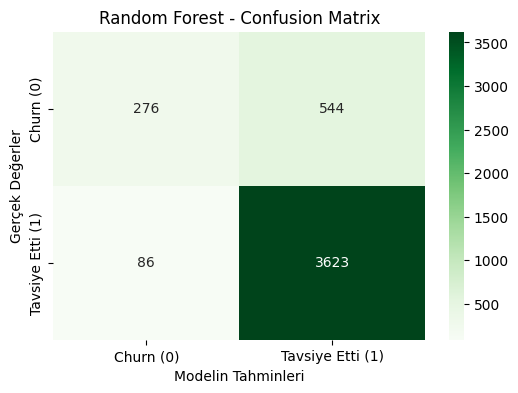

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Random Forest modeli eğitiliyor...")

# RandomForest Modeli
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

# Metrikler
print("\n" + "="*50)
print("🌲 MODEL PERFORMANS SONUÇLARI (RANDOM FOREST)")
print("="*50)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Genel Doğruluk (Accuracy): {rf_accuracy:.4f}\n")

print("Sınıflandırma Raporu (Classification Report):")
print(classification_report(y_test, y_pred_rf))

# Model Çıktılarının Görselleştirilmesi
plt.figure(figsize=(6, 4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=['Churn (0)', 'Tavsiye Etti (1)'], yticklabels=['Churn (0)', 'Tavsiye Etti (1)'])
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Gerçek Değerler')
plt.xlabel('Modelin Tahminleri')
plt.show()

📊 SMOTE Öncesi Eğitim Seti Sınıf Dağılımı:
Recommended IND
1    14831
0     3281
Name: count, dtype: int64

⚖️ SMOTE Sonrası Eğitim Seti Sınıf Dağılımı (Dengelenmiş):
Recommended IND
1    14831
0    14831
Name: count, dtype: int64

 Lojistik Regresyon, SMOTE ile dengelenmiş veriyle eğitiliyor...

🎯 SMOTE + LOJİSTİK REGRESYON SONUÇLARI
              precision    recall  f1-score   support

           0       0.59      0.82      0.69       820
           1       0.96      0.87      0.91      3709

    accuracy                           0.86      4529
   macro avg       0.77      0.85      0.80      4529
weighted avg       0.89      0.86      0.87      4529



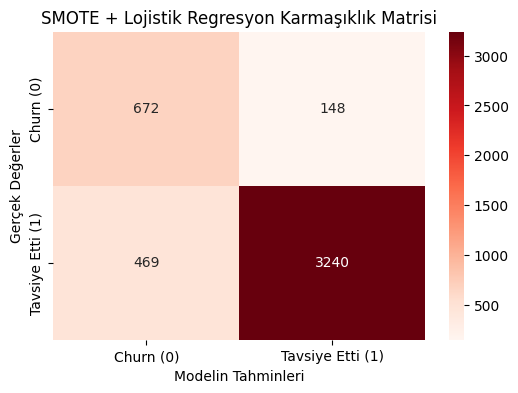

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("📊 SMOTE Öncesi Eğitim Seti Sınıf Dağılımı:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n⚖️ SMOTE Sonrası Eğitim Seti Sınıf Dağılımı (Dengelenmiş):")
print(y_train_smote.value_counts())

print("\n Lojistik Regresyon, SMOTE ile dengelenmiş veriyle eğitiliyor...")

rf_smote_model = LogisticRegression(max_iter=1000, random_state=42)
rf_smote_model.fit(X_train_smote, y_train_smote)

y_pred_smote = rf_smote_model.predict(X_test)

# Performans Değerlendirmesi
print("\n" + "="*50)
print("🎯 SMOTE + LOJİSTİK REGRESYON SONUÇLARI")
print("="*50)

print(classification_report(y_test, y_pred_smote))

# Görselleştirme
plt.figure(figsize=(6, 4))
cm_smote = confusion_matrix(y_test, y_pred_smote)
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Churn (0)', 'Tavsiye Etti (1)'],
            yticklabels=['Churn (0)', 'Tavsiye Etti (1)'])
plt.title('SMOTE + Lojistik Regresyon Karmaşıklık Matrisi')
plt.ylabel('Gerçek Değerler')
plt.xlabel('Modelin Tahminleri')
plt.show()

📊 SMOTE Öncesi Eğitim Seti Sınıf Dağılımı:
Recommended IND
1    14831
0     3281
Name: count, dtype: int64

⚖️ SMOTE Sonrası Eğitim Seti Sınıf Dağılımı (Dengelenmiş):
Recommended IND
1    14831
0    14831
Name: count, dtype: int64

🌲 Random Forest, SMOTE ile dengelenmiş veriyle eğitiliyor...

🎯 SMOTE + RANDOM FOREST SONUÇLARI
              precision    recall  f1-score   support

           0       0.68      0.55      0.61       820
           1       0.91      0.94      0.92      3709

    accuracy                           0.87      4529
   macro avg       0.79      0.75      0.77      4529
weighted avg       0.86      0.87      0.87      4529



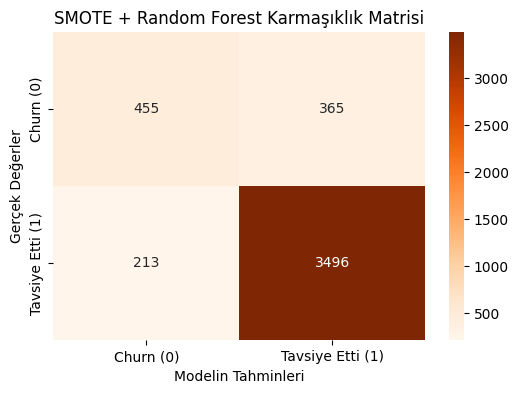

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("📊 SMOTE Öncesi Eğitim Seti Sınıf Dağılımı:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n⚖️ SMOTE Sonrası Eğitim Seti Sınıf Dağılımı (Dengelenmiş):")
print(y_train_smote.value_counts())

print("\n🌲 Random Forest, SMOTE ile dengelenmiş veriyle eğitiliyor...")

rf_smote_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smote_model.fit(X_train_smote, y_train_smote)

y_pred_smote = rf_smote_model.predict(X_test)

# Performans
print("\n" + "="*50)
print("🎯 SMOTE + RANDOM FOREST SONUÇLARI")
print("="*50)

print(classification_report(y_test, y_pred_smote))

# Görselleştirme
plt.figure(figsize=(6, 4))
cm_smote = confusion_matrix(y_test, y_pred_smote)
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Churn (0)', 'Tavsiye Etti (1)'],
            yticklabels=['Churn (0)', 'Tavsiye Etti (1)'])
plt.title('SMOTE + Random Forest Karmaşıklık Matrisi')
plt.ylabel('Gerçek Değerler')
plt.xlabel('Modelin Tahminleri')
plt.show()